In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('../data/craiglist_cville_cars_long.csv')
df.head()

,Unnamed: 0,title,price,year,link,brand,age,log_price,log_age,title.1,year_post,condition,cylinders,drivetrain,fuel,miles,color,transmission,bodytype,text
0,0,2005 hyundai elantra,1200,2005.0,https://charlottesville.craigslist.org/cto/d/a...,missing,20.0,7.090077,2.995732,title,2005,fair,4 cylinders,fwd,gas,232450,silver,manual,sedan,‘05 Elantra runs good but did not pass inspect...
1,1,2007 f250 king ranch,17500,2007.0,https://charlottesville.craigslist.org/cto/d/w...,missing,18.0,9.769956,2.890372,title,2007,good,8 cylinders,4wd,diesel,148086,missing,automatic,pickup,"6.0 diesel, bulletproofed, just replaced trans..."
2,2,1997 dodge 2500 4x4 cummins,9500,1997.0,https://charlottesville.craigslist.org/cto/d/l...,dodge,28.0,9.159047,3.332205,title,1997,fair,6 cylinders,4wd,diesel,179000,red,automatic,truck,1997 Dodge 4x4 Cummins. Adult owned and driven...
3,3,1999 honda civic 4 cyl manual transmission,1000,1999.0,https://charlottesville.craigslist.org/cto/d/c...,honda,26.0,6.907755,3.258097,title,1999,salvage,4 cylinders,rwd,gas,195338,silver,manual,sedan,"Vehicle does start and run, it has a manual tr..."
4,4,"1998 gmc sierra 1500 sl truck auto rwd <103,00...",6250,1998.0,https://charlottesville.craigslist.org/cto/d/l...,gmc,27.0,8.740337,3.295837,title,1998,good,8 cylinders,rwd,gas,102483,missing,automatic,truck,"1998 GMC Sierra 1500 SL Truck, Auto 2WD/RWD, V..."


In [32]:
from sklearn.linear_model import LinearRegression

df = df.dropna()
df2 = df.loc[:, ['price', 'age', 'miles']].dropna()

y = df2['price']
x = df2.drop(columns=['price'])

model = LinearRegression().fit(x, y)

print(f'intercept: {model.intercept_}')
pd.DataFrame({'variable': model.feature_names_in_, 'coefficient': model.coef_})

intercept: 22420.36180255221


,variable,coefficient
0,age,-90.739677
1,miles,-0.078672


interpretation: for every mile, the price goes down by about 7 cents

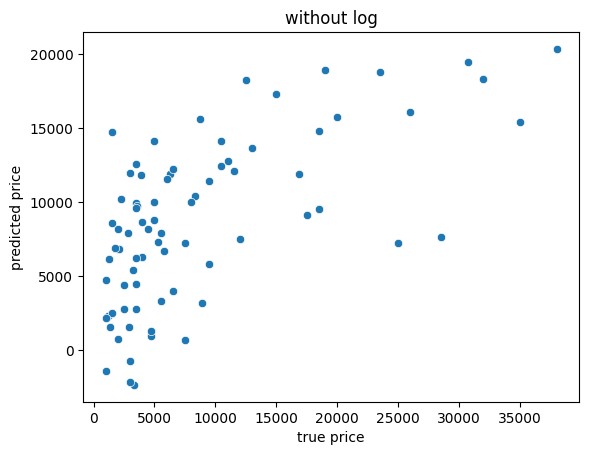

In [33]:
y_hat = model.predict(x)

sns.scatterplot(x=y, y=y_hat)
plt.title('without log')
plt.xlabel('true price')
plt.ylabel('predicted price')
plt.show()

we want that graph to show the points along the diagonal, but that doesn't really happen

<Axes: xlabel='price', ylabel='Density'>

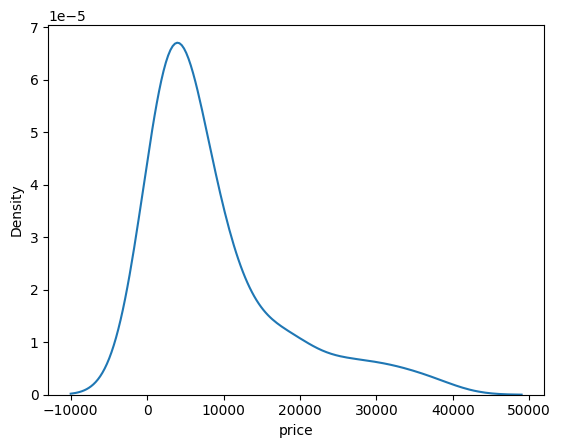

In [34]:
sns.kdeplot(df2['price'])

so we make this a bit better using the log

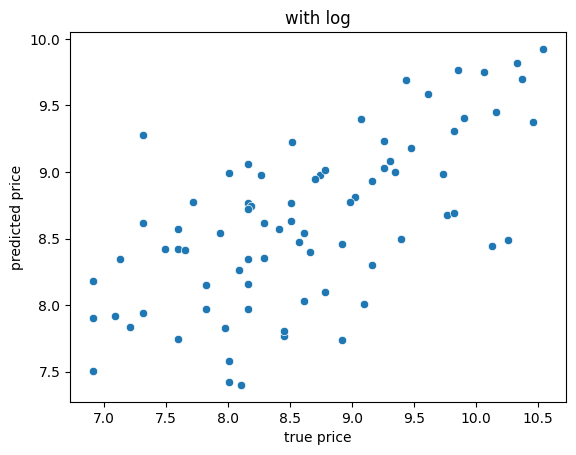

In [35]:
y = np.log(df2['price'])
x = df2.drop(columns=['price'])

model = LinearRegression().fit(x, y)

y_hat = model.predict(x)

sns.scatterplot(x=y, y=y_hat)
plt.title('with log')
plt.xlabel('true price')
plt.ylabel('predicted price')
plt.show()

### looking at brand

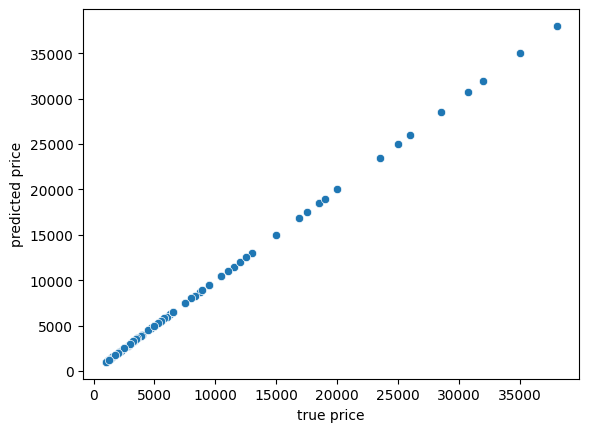

In [42]:
df3 = df.loc[:,['price', 'miles', 'age', 'brand']].dropna()

y = df3['price']
xnum = df3.drop(columns=['brand'])
xcat = pd.get_dummies(df3['brand'], dtype=int, drop_first=True)
x = pd.concat([xnum, xcat], axis=1)

model = LinearRegression().fit(x, y)

y_hat = model.predict(x)

sns.scatterplot(x=y, y=y_hat)
plt.xlabel('true price')
plt.ylabel('predicted price')
plt.show()

In [53]:
iowa = pd.read_csv('../data/iowa.csv')
iowa.head()

,Invoice/Item Number,Date,Store Number,Store Name,Zip Code,Category Name,Vendor Name,Item Number,Item Description,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars)
0,INV-59108400026,06/06/2023,3723,J D SPIRITS LIQUOR,51040,STRAIGHT RYE WHISKIES,INFINIUM SPIRITS,27102,TEMPLETON RYE 4YR,750,18.09,27.14,2,54.28
1,S16879800057,01/16/2014,3926,LIQUOR DOWNTOWN / IOWA CITY,52240,VODKA 80 PROOF,HEAVEN HILL BRANDS,35416,BURNETT'S VODKA 80 PRF,750,4.84,7.26,12,87.12
2,INV-05301100019,06/05/2017,3829,GARY'S FOODS / MT VERNON,52314,CANADIAN WHISKIES,DIAGEO AMERICAS,11296,CROWN ROYAL,750,15.59,23.39,6,135.66
3,INV-40973500083,10/14/2021,5102,WILKIE LIQUORS,52314,AMERICAN SCHNAPPS,JIM BEAM BRANDS,82787,DEKUYPER BUTTERSHOTS,1000,7.87,11.81,12,141.72
4,INV-17022500013,01/18/2019,2560,HY-VEE FOOD STORE / MARION,52302,WHISKEY LIQUEUR,SAZERAC COMPANY INC,64863,FIREBALL CINNAMON WHISKEY,200,2.50,3.75,12,45.00


In [59]:
#iowa['Category Name'] = iowa['Category Name'].str.split()
iowa['catsplit'] = iowa['Category Name'].str.split()
iowa.head()

,Invoice/Item Number,Date,Store Number,Store Name,Zip Code,Category Name,Vendor Name,Item Number,Item Description,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars),catsplit
0,INV-59108400026,06/06/2023,3723,J D SPIRITS LIQUOR,51040,STRAIGHT RYE WHISKIES,INFINIUM SPIRITS,27102,TEMPLETON RYE 4YR,750,18.09,27.14,2,54.28,"[STRAIGHT, RYE, WHISKIES]"
1,S16879800057,01/16/2014,3926,LIQUOR DOWNTOWN / IOWA CITY,52240,VODKA 80 PROOF,HEAVEN HILL BRANDS,35416,BURNETT'S VODKA 80 PRF,750,4.84,7.26,12,87.12,"[VODKA, 80, PROOF]"
2,INV-05301100019,06/05/2017,3829,GARY'S FOODS / MT VERNON,52314,CANADIAN WHISKIES,DIAGEO AMERICAS,11296,CROWN ROYAL,750,15.59,23.39,6,135.66,"[CANADIAN, WHISKIES]"
3,INV-40973500083,10/14/2021,5102,WILKIE LIQUORS,52314,AMERICAN SCHNAPPS,JIM BEAM BRANDS,82787,DEKUYPER BUTTERSHOTS,1000,7.87,11.81,12,141.72,"[AMERICAN, SCHNAPPS]"
4,INV-17022500013,01/18/2019,2560,HY-VEE FOOD STORE / MARION,52302,WHISKEY LIQUEUR,SAZERAC COMPANY INC,64863,FIREBALL CINNAMON WHISKEY,200,2.50,3.75,12,45.00,"[WHISKEY, LIQUEUR]"


In [ ]:
# iowa2 = iowa.loc[:, ['']]